In [3]:
import cv2
from pathlib import Path
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator, Colors
from matplotlib import pyplot as plt

# --- Configuration ---
# Choisissez le modèle à utiliser : 0: nano, 1: small, 2: medium
# Le modèle nano est le plus rapide, le medium est le plus précis.
MODEL_INDEX = 0 
MODEL_FILES = [
    "yolo11n_doc_layout.pt",
    "yolo11s_doc_layout.pt",
    "yolo11m_doc_layout.pt",
]
SELECTED_MODEL_FILE = MODEL_FILES[MODEL_INDEX]

# Chemin vers votre image de document
IMAGE_PATH = "../images/doc1.png" # <--- MODIFIEZ CECI

# --- Téléchargement du modèle ---
# Crée un dossier pour stocker les modèles téléchargés
DOWNLOAD_PATH = Path("./models")
DOWNLOAD_PATH.mkdir(exist_ok=True)

# Télécharge le modèle depuis le Hub Hugging Face s'il n'est pas déjà présent
try:
    model_path = hf_hub_download(
        repo_id="Armaggheddon/yolo11-document-layout",
        filename=SELECTED_MODEL_FILE,
        repo_type="model",
        local_dir=DOWNLOAD_PATH,
    )
    print(f"Modèle téléchargé à l'emplacement : {model_path}")
except Exception as e:
    print(f"Erreur lors du téléchargement du modèle : {e}")
    exit()


Modèle téléchargé à l'emplacement : models/yolo11n_doc_layout.pt


In [20]:

# --- Inférence ---
# Charge le modèle YOLO
model = YOLO(model_path)

# Charge l'image
img = cv2.imread(IMAGE_PATH)
if img is None:
    print(f"Erreur : Impossible de charger l'image depuis {IMAGE_PATH}")
    exit()

# Effectue la prédiction
results = model.predict(img)

# --- Visualisation des résultats ---
# Crée un objet pour annoter l'image
annotator = Annotator(img, line_width=2, font_size=8)
colors = Colors() # Pour avoir des couleurs distinctes par classe



0: 1280x928 4 List-items, 1 Page-header, 4 Pictures, 14 Section-headers, 1 Table, 10 Texts, 152.4ms
Speed: 5.8ms preprocess, 152.4ms inference, 2.0ms postprocess per image at shape (1, 3, 1280, 928)


✅ Table extraite et zoomée : table_crop_0.png


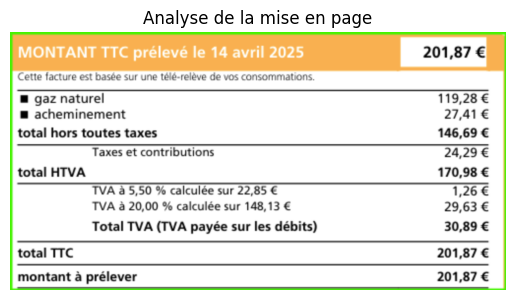

In [23]:
TARGET_CLASS = "Table"
crop_count = 0  # compteur pour nommer les fichiers

for result in results:
    boxes = result.boxes
    for box in boxes:
        c = int(box.cls.item())
        class_name = model.names[c]

        if class_name != TARGET_CLASS:
            continue

        # Bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        # Dessine la box sur l'image principale
        conf = box.conf.item()
        label = f"{class_name} {conf:.2f}"
        annotator.box_label(box.xyxy[0], label, color=colors(c, True))

        # ---- CROP ET ZOOM ----
        crop = img[y1:y2, x1:x2]

        # Zoom (2x ici — change la valeur si besoin)
        zoom_factor = 2
        crop_zoom = cv2.resize(
            crop, 
            (crop.shape[1] * zoom_factor, crop.shape[0] * zoom_factor),
            interpolation=cv2.INTER_LINEAR
        )

        # Sauvegarder l'image zoomée
        crop_path = f"table_crop_{crop_count}.png"
        cv2.imwrite(crop_path, crop_zoom)
        print(f"✅ Table extraite et zoomée : {crop_path}")
        crop_count += 1

annotated_img = annotator.result()
plt.title("Analyse de la mise en page")
plt.imshow(crop_zoom, cmap='gray')  
plt.axis("off")

plt.show()


In [15]:

# Parcours les détections
for result in results:
    boxes = result.boxes
    for box in boxes:
        # Récupère les coordonnées de la boîte englobante
        b = box.xyxy[0]  # format (x1, y1, x2, y2)
        # Récupère la classe (type d'élément) et la confiance
        c = box.cls
        conf = box.conf.item()
        label = f"{model.names[int(c)]} {conf:.2f}"
        
        # Dessine la boîte et le label sur l'image
        annotator.box_label(b, label, color=colors(c, True))

# Récupère l'image annotée
annotated_img = annotator.result()


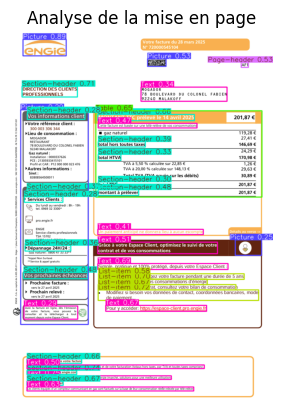

In [9]:


plt.title("Analyse de la mise en page")
plt.imshow(annotated_img, cmap='gray')  
plt.axis("off")

plt.show()

In [10]:
# Sauvegarde l'image avec les détections
output_path = "resultat_analyse.png"
cv2.imwrite(output_path, annotated_img)
print(f"Image sauvegardée à l'emplacement : {output_path}")

Image sauvegardée à l'emplacement : resultat_analyse.png
